In [10]:
import numpy as np
from os import listdir

from ExistingAlgorithms.Plot import plot_traces
from AutoencoderAPI.utils.files import load_mean_std
from AutoencoderAPI.utils.decibels import file_name_table_npy, decibel_table_bin
from AutoencoderAPI.utils.correlation import second_order
from AutoencoderAPI.utils.confidence import confidence
from AutoencoderAPI.autoencoderGaussianMixture import autoencoder_gaussianMixture
from AutoencoderAPI.loadAutoencoder import loadAutoencoder

import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from sklearn.manifold import TSNE
from AutoencoderAPI.utils.clustering.densityGaussianMixture import density_gaussianMixture
from sklearn.decomposition import PCA

In [11]:
signal_size = 30_000
path_train = 'Datasets/TES/NIST test'
path_model = 'grid-search-TES param 4/run 14/fold 0'#run-2024-01-18-18-15/fold 0'
mean_model, std_model = load_mean_std(path_model)

# Poissonian statistic for Autoencoder

In [12]:
X, decibel_samples = decibel_table_bin('Datasets/TES/NIST test',
                                8192,
                                (67,71))

X = -1* X[:,0:270]
X = (X - mean_model) / std_model
#X = X[:,::2]

In [13]:
decibel = []
g2 = []
average = []

X_i_AUTO, X_r_AUTO, X_l_AUTO = loadAutoencoder(X, f'AutoencoderLog/{path_model}', filter=False, flip=False)

conf = confidence(X_l_AUTO,
                bw = [0.008], 
                bins_plot = 5000,
                min_cluster_prob=0.001,
                density_kernel='gaussian',
                flip = True, 
                skip = 5,
                size_plot = 10)

labels = conf.labels

for index, key in enumerate(np.unique(decibel_samples)):

    print(key)
    condition = decibel_samples == key

    conf.fit(X_l_AUTO[condition],
            bw = [0.0023], 
            bins_plot = 5000,
            min_cluster_prob=0.001,
            density_kernel='gaussian',
            flip = False, 
            skip = 5,
            size_plot = 10)
    
    labels_ = labels[condition]

    decibel.append(key)
    g2.append(second_order(labels_))
    average.append(np.mean(labels_))

KeyboardInterrupt: 

# dB evaluation

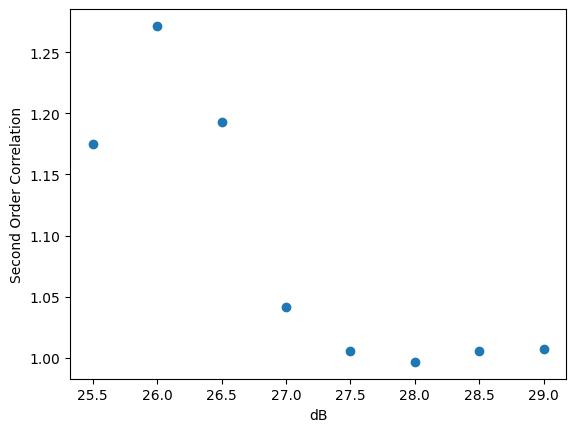

In [12]:
plt.figure()
plt.scatter(decibel, g2, marker='o')
plt.xlabel("dB")
plt.ylabel("Second Order Correlation")
plt.show()

In [6]:
def function(dB, n_0, cst):
    dB = np.array(dB)
    return n_0 * 10**(-cst*dB )

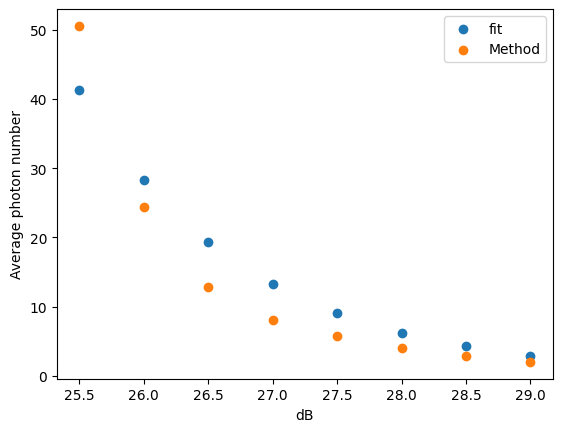

[1.00000000e+10 3.28759638e-01]


In [7]:

popt, pcov = curve_fit(function, decibel, average, 
                       bounds=([0, -100], [1e10, 100]),
                       p0=[4,0.1])
plt.figure()
plt.scatter(decibel, function(decibel, *popt), label='fit')
plt.scatter(decibel, average,marker='o', label='Method')
plt.xlabel("dB")
plt.ylabel("Average photon number")
plt.legend()
plt.show()
print(popt)

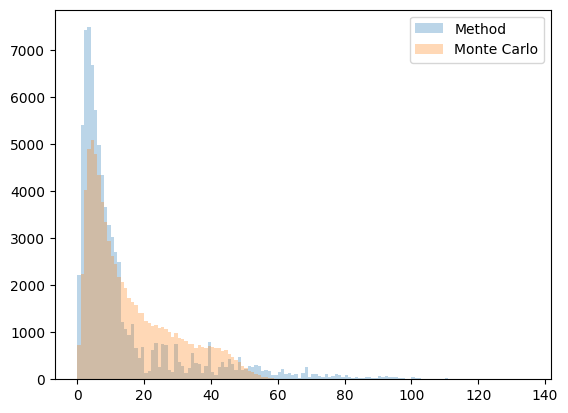

In [9]:
import numpy.random as npr

average_ = function(decibel, *popt)
n = np.concatenate([npr.poisson(i, 10_000) for i in average_])
plt.figure()
plt.hist(labels, alpha=0.3, bins=np.unique(labels), label='Method')
plt.hist(n, alpha=0.3, bins=np.unique(n), label='Monte Carlo')
plt.legend()
plt.show()

# Poissonian statistic for t-SNE

In [5]:
X, decibel_samples = decibel_table_bin('Datasets/TES/NIST train',
                                8192,
                                (67,71))

X = -1* X[:,0:270]
X = X[:,::2]

In [10]:
#method = TSNE(n_components=1, perplexity=1000)
#X_l = method.fit_transform(X)

In [8]:
#np.save("temp_tsne_TES1000_L",X_l)
X_l = np.load("MetricLog/temp_tsne_TES1000_100.npy")

/home/nicolasdc/files/Photon-Number-Classification/src/AutoencoderAPI/utils/clustering/densityGaussianMixture.py:108: RuntimeWarning: invalid value encountered in sqrt
  mins[i] = (u2*sig1**2 - sig2*(u1*sig2 + sig1*sqrt((u1-u2)**2 + 2*(sig1**2-sig2**2)*log((sig1* coeff2) / (sig2* coeff1)))))/(sig1**2 - sig2**2)


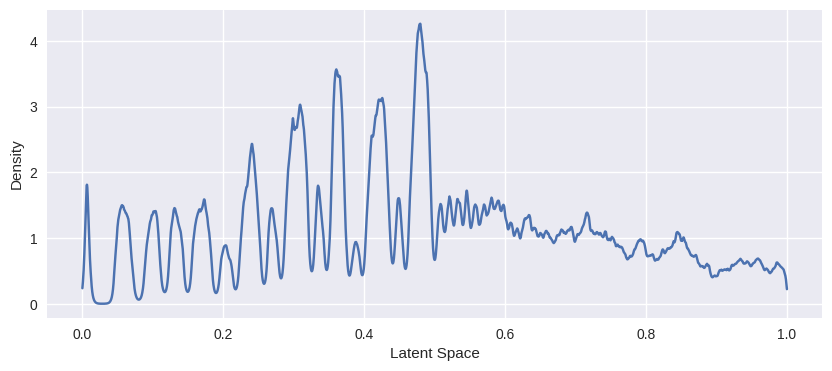

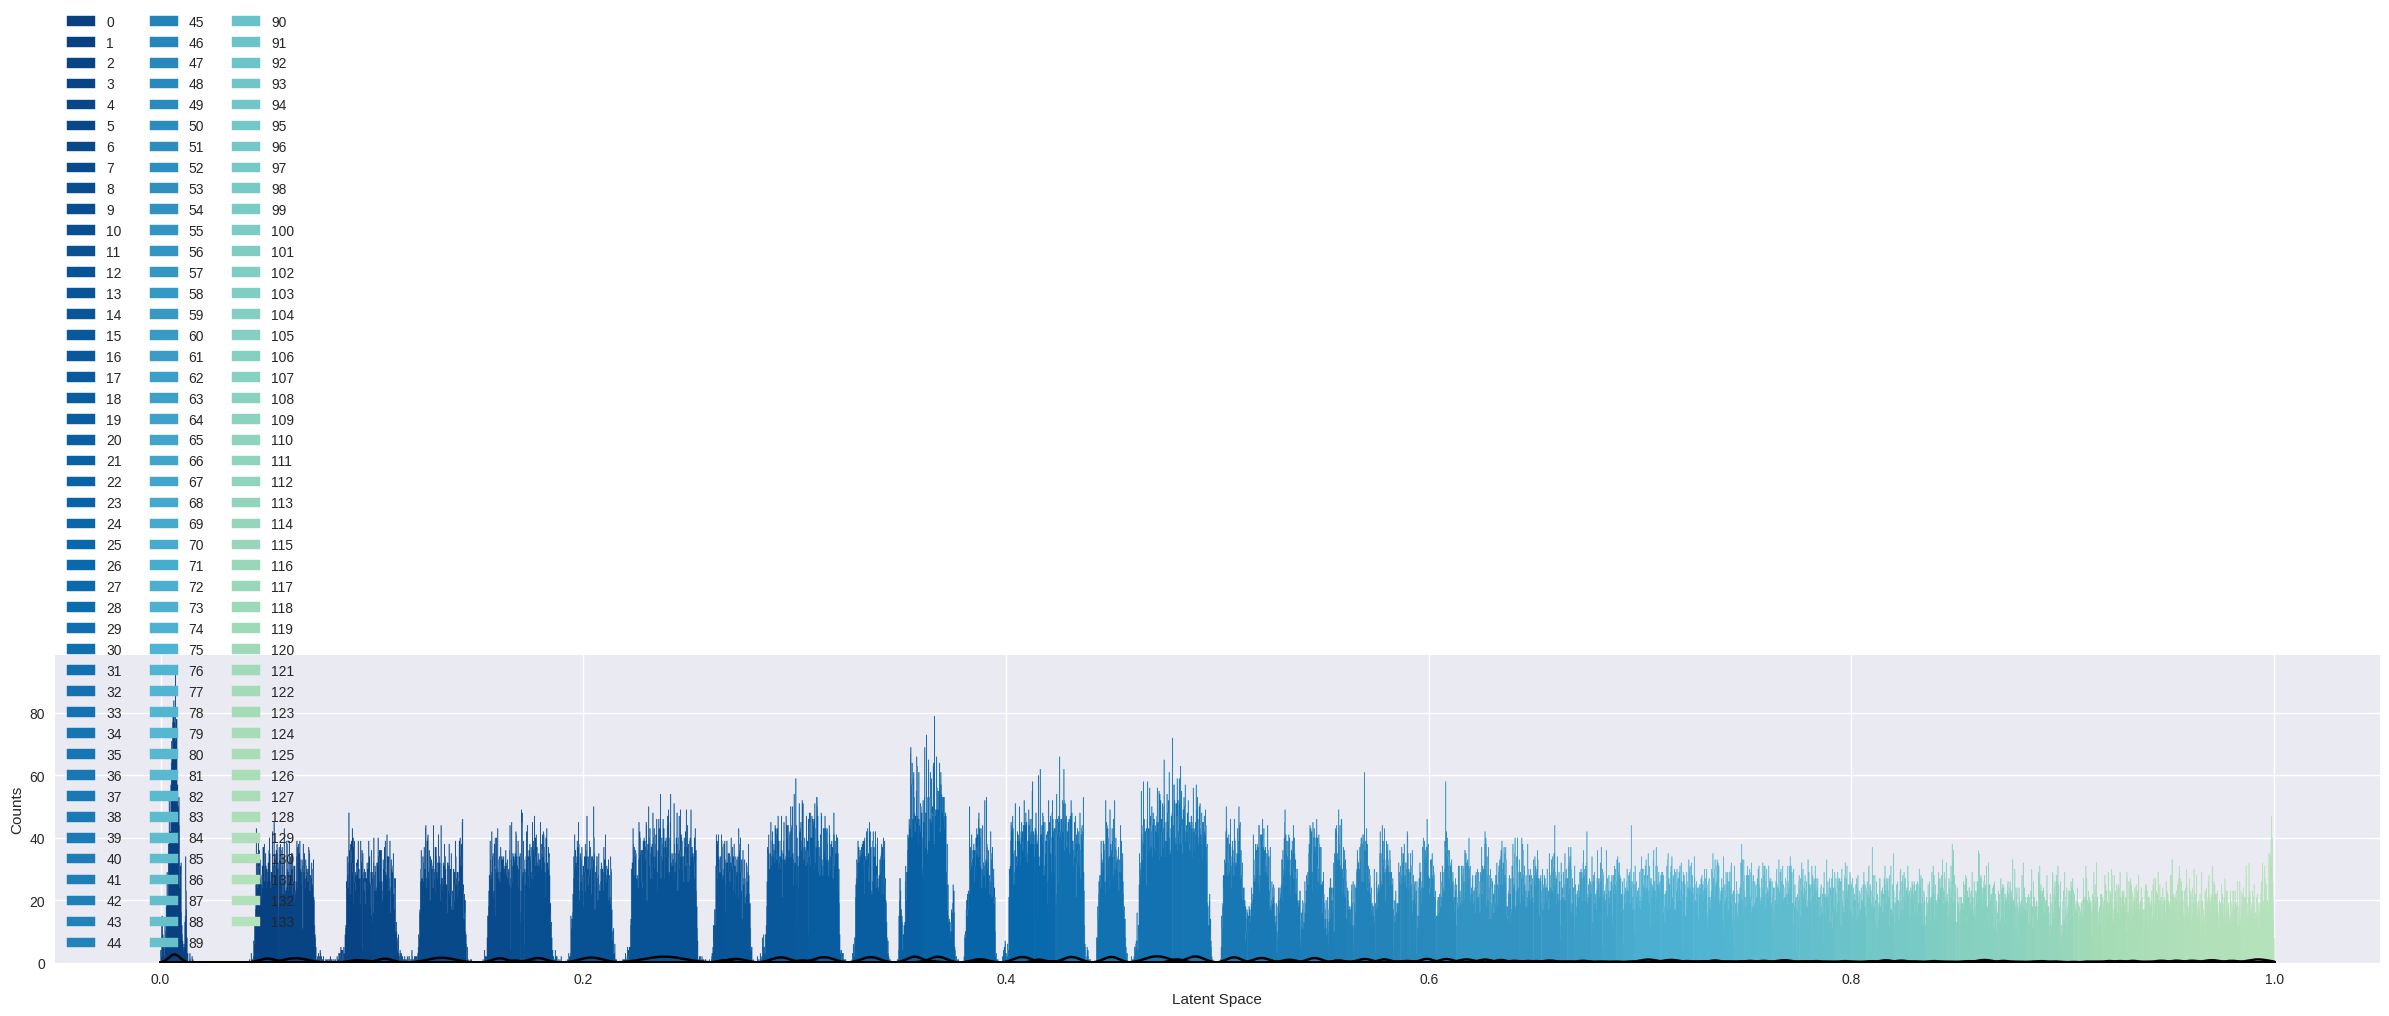

IndexError: boolean index did not match indexed array along dimension 0; dimension is 81920 but corresponding boolean dimension is 123904

<Figure size 3000x400 with 0 Axes>

In [9]:
X_l = (X_l - np.min(X_l)) / (np.max(X_l) - np.min(X_l))

kd = density_gaussianMixture(X_l, 
                            bw = [0.005], #0.012
                            bins_plot = 5000,
                            density_kernel='exponential',
                            flip = False, 
                            skip = 10,
                            size_plot = 30)

kd.plot_density()
kd.plot_cluster()
kd.plot_traces_average(X)
labels = kd.labels

In [ ]:
decibel = []
g2 = []
average = []
bw = []

for index, key in enumerate(np.unique(decibel_samples)):

    print(key)
    condition = decibel_samples == key
    labels_ = labels[condition]

    decibel.append(key)
    g2.append(second_order(labels_))
    average.append(np.mean(labels_))

23.5
24.0
24.5
25.0
25.5
26.0
26.5
27.0
27.5
28.0
28.5
29.0


# dB evaluation

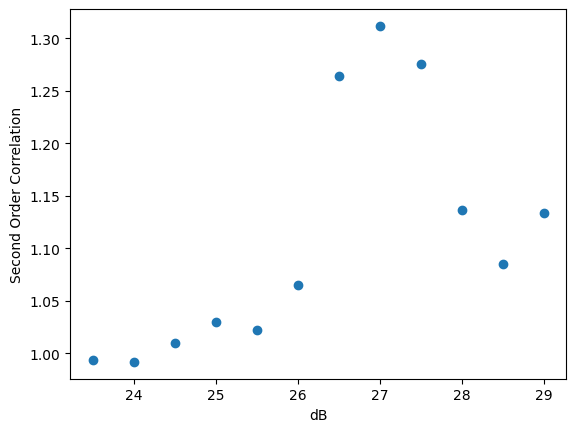

In [ ]:
plt.figure()
plt.scatter(decibel, g2, marker='o')
plt.xlabel("dB")
plt.ylabel("Second Order Correlation")
plt.show()

In [ ]:
def function(dB, n_0, cst):
    dB = np.array(dB)
    return n_0 * 10**(-cst*dB )

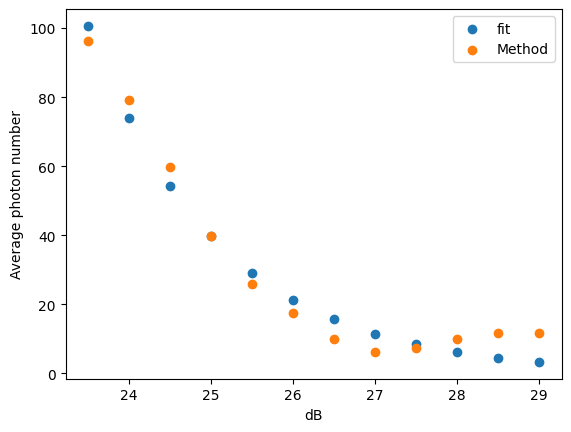

[2.10437081e+08 2.68952385e-01]


In [ ]:

popt, pcov = curve_fit(function, decibel, average, 
                       bounds=([0, -100], [1e9, 100]),
                       p0=[4,0.1])
plt.figure()
plt.scatter(decibel, function(decibel, *popt), label='fit')
plt.scatter(decibel, average,marker='o', label='Method')
plt.xlabel("dB")
plt.ylabel("Average photon number")
plt.legend()
plt.show()
print(popt)

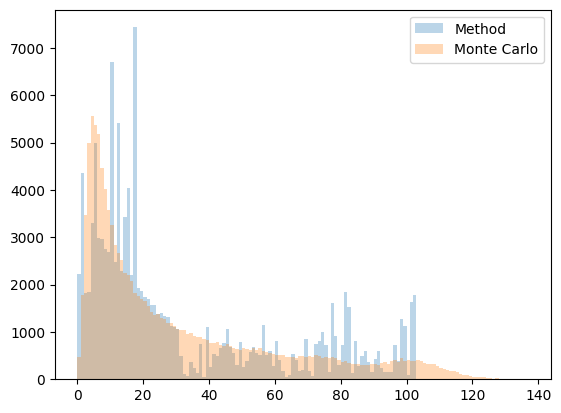

In [ ]:
import numpy.random as npr

average_ = function(decibel, *popt)
n = np.concatenate([npr.poisson(i, 10_000) for i in average_])
plt.figure()
plt.hist(labels, alpha=0.3, bins=np.unique(labels), label='Method')
plt.hist(n, alpha=0.3, bins=np.unique(n), label='Monte Carlo')
plt.legend()
plt.show()

# Poissonian statistics for PCA

In [ ]:
X, decibel_samples = decibel_table_bin('Datasets/TES/NIST train',
                                8192,
                                (67,71))

X = -1* X[:,0:250]
X = X[:, ::2]

In [ ]:
method = PCA(n_components=1)
X_l = method.fit_transform(X)

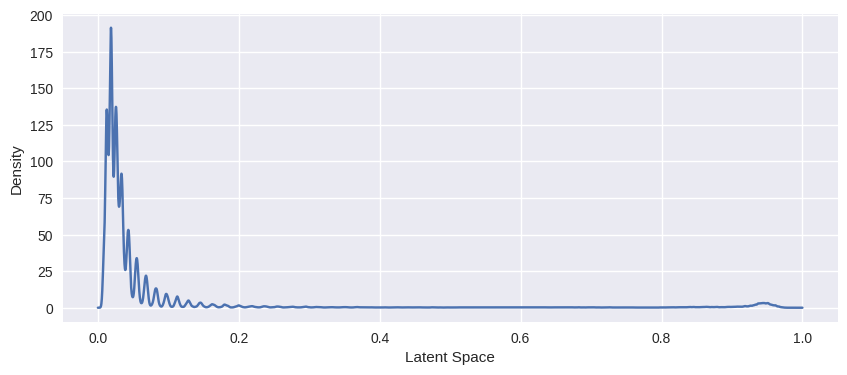

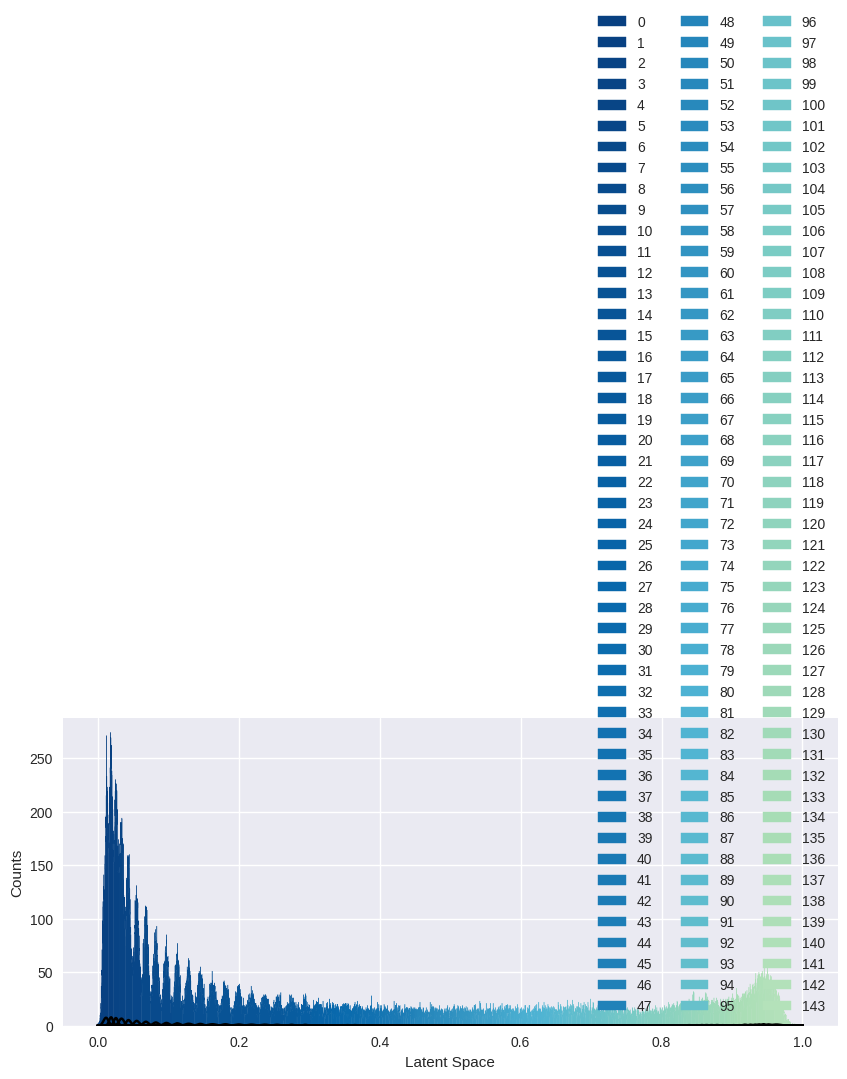

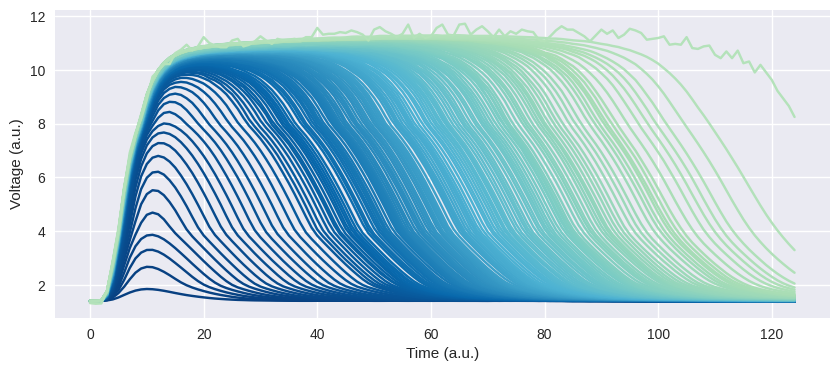

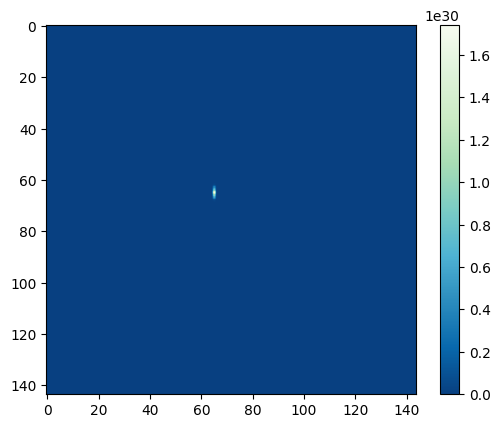

In [ ]:
X_l = (X_l - np.min(X_l)) / (np.max(X_l) - np.min(X_l))

kd = density_gaussianMixture(X_l, 
                            bw = [0.001], 
                            bins_plot = 5000,
                            flip = False, 
                            skip = 0)
kd.plot_density()
kd.plot_cluster()
kd.plot_traces_average(X)
kd.plot_cross_talk()
labels = kd.labels

In [ ]:
decibel = []
g2 = []
average = []
bw = []

for index, key in enumerate(np.unique(decibel_samples)):

    print(key)
    condition = decibel_samples == key
    labels_ = labels[condition]

    decibel.append(key)
    g2.append(second_order(labels_))
    average.append(np.mean(labels_))

23.5
24.0
24.5
25.0
25.5
26.0
26.5
27.0
27.5
28.0
28.5
29.0


# dB evaluation

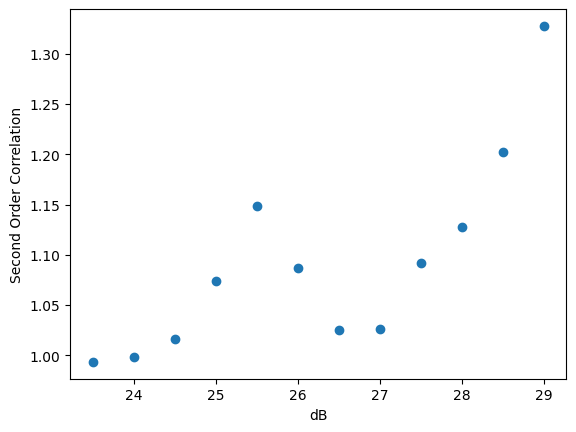

In [ ]:
plt.figure()
plt.scatter(decibel, g2, marker='o')
plt.xlabel("dB")
plt.ylabel("Second Order Correlation")
plt.show()

In [ ]:
def function(dB, n_0, cst):
    dB = np.array(dB)
    return n_0 * 10**(-cst*dB )

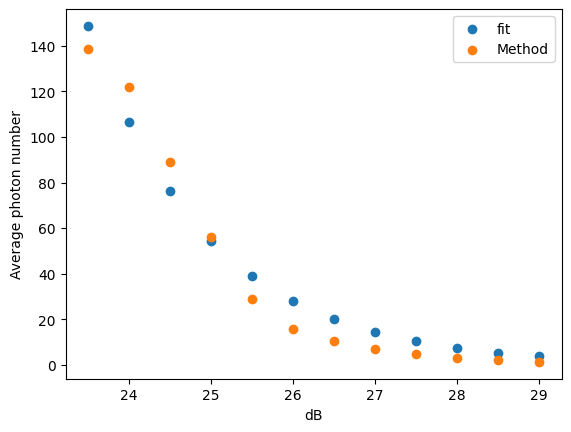

[1.00000000e+09 2.90532908e-01]


In [ ]:

popt, pcov = curve_fit(function, decibel, average, 
                       bounds=([0, -100], [1e9, 100]),
                       p0=[4,0.1])
plt.figure()
plt.scatter(decibel, function(decibel, *popt), label='fit')
plt.scatter(decibel, average,marker='o', label='Method')
plt.xlabel("dB")
plt.ylabel("Average photon number")
plt.legend()
plt.show()
print(popt)

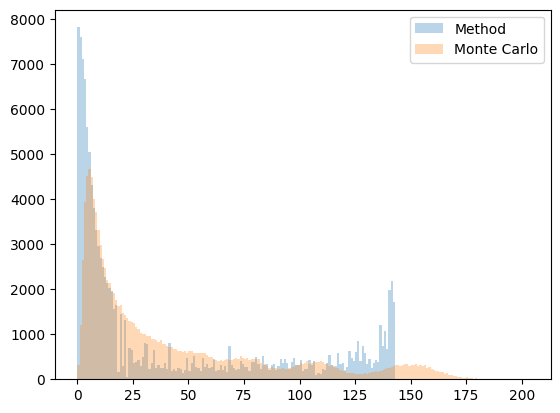

In [ ]:
import numpy.random as npr

average_ = function(decibel, *popt)
n = np.concatenate([npr.poisson(i, 10_000) for i in average_])
plt.figure()
plt.hist(labels, alpha=0.3, bins=np.unique(labels), label='Method')
plt.hist(n, alpha=0.3, bins=np.unique(n), label='Monte Carlo')
plt.legend()
plt.show()